# Modelos generativos de texto

Veremos passo-a-passo como usar um modelo generativo de texto do Hugginface. Veremos dois tipos de modelos:

1. Modelos treinados apenas para completar textos
2. Modelos refinados para conversa com o usuário

É importante salientar que a biblioteca Hugginface possui os chamados *pipelines*, que permitem fazer o que veremos neste notebook de forma mais fácil. Mas pipelines abstraem totalmente os passos intermediários do processo.

\* Este notebook necessita apenas de 2GB de memória de GPU para rodar.

### Modelo de geração de texto Qwen

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

device = "cuda"

# Outros modelos possíveis:
# Qwen3.5-2B, Qwen3.5-4B, Qwen3.5-9B, Qwen3.5-27B, Qwen3.5-35B-A3B, Qwen3.5-122B-A10B, Qwen3.5-397B-A17B
name = "Qwen/Qwen3.5-0.8B"

# O uso da biblioteca bitsandbytes permite a quantização dos pesos para reduzir uso de memória
quantization_config = BitsAndBytesConfig(load_in_4bit=True)

model = AutoModelForCausalLM.from_pretrained(
    name, 
    torch_dtype="auto",          # Precisão para criar o modelo antes de carregar os pesos
    device_map="auto",           # Carrega os pesos na GPU até o limite de memória. Se precisar 
                                 # de mais memória, o restante do modelo é carregado na CPU.
    quantization_config=quantization_config   # Estratégia de quantização
    )
tokenizer = AutoTokenizer.from_pretrained(
    name, 
    padding_side="left"         # Onde inserir o token de padding para criar batches de entrada
    )

# O modelo Qwen não foi treinado com um token de padding, mas ele é necessário para a inferência
# utilizando batches. Podemos usar o token de final de sentença para representar o padding. Esse
# token não é utilizado na atenção do modelo, então não deve afetar a geração de texto.
tokenizer.pad_token = tokenizer.eos_token
model.generation_config.pad_token_id = tokenizer.eos_token_id

In [2]:
# Tokenização de duas sentenças de texto
texts = ["A list of colors: red, blue", "1, 2"]
model_inputs = tokenizer(texts, padding=True, return_tensors="pt").to(device)
model_inputs

{'input_ids': tensor([[    32,   1103,    314,   7736,     25,   2438,     11,   6105],
        [248046, 248046, 248046, 248046,     16,     11,    220,     17]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 1, 1]], device='cuda:0')}

In [3]:
# Decodificação dos tokens. Note que tokens extra de padding foram adicionados
tokenizer.batch_decode(model_inputs.input_ids)

['A list of colors: red, blue', '<|im_end|><|im_end|><|im_end|><|im_end|>1, 2']

In [4]:
# A primeira camada do modelo é a camada de embedding. Ela transforma cada um dos 248320 tokens 
# possíveis em um vetor possuindo 1024 valores. Usualmente, modelos treinados apenas no idioma 
# inglês possuem em torno de 40k tokens. Modelos multilinguagem precisam de mais tokens para 
# representar palavras em diferentes idiomas.
model.model.embed_tokens

Embedding(248320, 1024)

In [5]:
embeddings = model.model.embed_tokens(model_inputs.input_ids)
embeddings.shape
# Saída possui tamanho bs x nro de tokens x d_model

torch.Size([2, 8, 1024])

In [6]:
# Aplicação do modelo
output = model(**model_inputs)
output = output.logits
output.shape
# Saída possui tamanho bs x nro de tokens x n_vocab

torch.Size([2, 8, 248320])

A saída do modelo pode ser interpretada se seguinte forma. O vetor `output[0, i]` possui 248320 valores associados com os tokens de 0 a i-1 da sentença de entrada. Esse vetor representa os scores gerados pelo modelo para cada um dos 248320 tokens do vocabulário. Quanto maior o valor do score, maior a chance de que o respectivo token apareça após os tokens de 0 a i-1.

A saída possui esse padrão pois é assim que o modelo é treinado. Os tokens de 0 a i-1 são usados para prever o token i, e a função loss é calculada para cada valor de i. Mas para a inferência precisamos apenas dos scores do último token:

In [7]:
next_token_logits = output[:, -1]
print(next_token_logits.shape)

torch.Size([2, 248320])


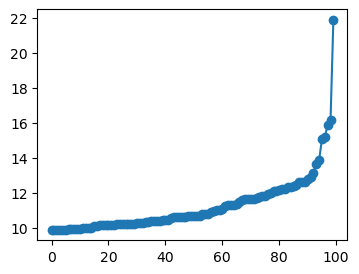

In [8]:
import matplotlib.pyplot as plt

# Scores gerados para completar a sentença 0:
probs = next_token_logits[0]
probs = probs.detach().float().cpu().sort().values
plt.plot(probs[-100:], "-o")

In [9]:
# Geração de texto. O modelo simplesmente encontra os tokens com maior probabilidade 
# de completar os tokens de entrada
# O resultado da geração consiste em "nro tokens de entrada + max_new_tokens".
# Veja https://huggingface.co/docs/transformers/en/generation_strategies para mais detalhes
# sobre as estratégias de geração
generated_ids = model.generate(**model_inputs, max_new_tokens = 20)
generated_ids

tensor([[    32,   1103,    314,   7736,     25,   2438,     11,   6105,     11,
           5983,     11,  13358,     11,   3565,     11,   4022,     11,  17676,
             11,  24142,     11,  18016,     11,  13477,     11,  17024,     11,
          91338],
        [248046, 248046, 248046, 248046,     16,     11,    220,     17,     11,
            220,     18,     11,    220,     19,     11,    220,     20,     11,
            220,     21,     11,    220,     22,     11,    220,     23,     11,
            220]], device='cuda:0')

In [10]:
tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

['A list of colors: red, blue, green, yellow, black, white, pink, purple, orange, brown, gray, teal',
 '1, 2, 3, 4, 5, 6, 7, 8, ']

Como o modelo gerou diversas palavras?

Para cada novo token a ser gerado, a sequência inteira é passada pelo modelo para gerar atributos para o **último token da sequência de saída**. Inicialmente, a sequência possui 9 tokens e um novo token é gerado. Para gerar o próximo token, o novo token é concatenado ao final da sequência, criando uma sequência de 10 tokens. Essa sequência é então a nova entrada do modelo, e o próximo token é gerado. O processo continua até que a sequência possua tamanho `max_new_tokens`.

### Modelo com refinamento de instrução

Modelos *instruct* foram treinados para conversação. O modelo gera palavras que representem uma conversa natural com o usuário

Um modelo com instrução possui um template que indica como uma conversa deve ser formatada. Tipicamente, uma conversa possui os seguintes atores:

1. system: Texto que é adicionado no começo da conversa ou a **todas as entradas do usuário**. Tipicamente, esse texto envolve instruções de como o modelo deve se 'comportar' durante toda a conversa. 
2. user: Representa o usuário
3. assistant: Representa o modelo

A conversa também pode ter artefatos como ferramentas (tools) e documentos. Esses artefatos não serão vistos neste notebook.

Uma conversa é representada por um conjunto de mensagens, que são transformadas em uma única string:

In [23]:
# Exemplo de instrução de sistema e mensagem do usuário
messages = [
    {
        "role": "system",
        "content": "You are a friendly chatbot who always greets the user before answering.",
    },
    {
        "role": "user", 
        "content": "How many hours are in a day?"
    },
]

# Conversão da conversa em uma string
text = tokenizer.apply_chat_template(
    messages, 
    tokenize=False,
    add_generation_prompt=True   # Adiciona o texto assistant ao final da string para guiar o modelo
    )
print(text)

<|im_start|>system
You are a friendly chatbot who always greets the user before answering.<|im_end|>
<|im_start|>user
How many hours are in a day?<|im_end|>
<|im_start|>assistant
<think>

</think>




A string gerada acima possui um cabeçalho (system) com instruções para guiar o modelo, incluindo a data que o modelo foi treinado e a data atual, para que o modelo possa responder adequadamente perguntas que ultrapassem a data de treinamento.

A lista de mensagens é transformada em uma string através de um template Jinja:

In [12]:
print(tokenizer.chat_template)

{%- set image_count = namespace(value=0) %}
{%- set video_count = namespace(value=0) %}
{%- macro render_content(content, do_vision_count, is_system_content=false) %}
    {%- if content is string %}
        {{- content }}
    {%- elif content is iterable and content is not mapping %}
        {%- for item in content %}
            {%- if 'image' in item or 'image_url' in item or item.type == 'image' %}
                {%- if is_system_content %}
                    {{- raise_exception('System message cannot contain images.') }}
                {%- endif %}
                {%- if do_vision_count %}
                    {%- set image_count.value = image_count.value + 1 %}
                {%- endif %}
                {%- if add_vision_id %}
                    {{- 'Picture ' ~ image_count.value ~ ': ' }}
                {%- endif %}
                {{- '<|vision_start|><|image_pad|><|vision_end|>' }}
            {%- elif 'video' in item or item.type == 'video' %}
                {%- if is_s

In [24]:
# Criação dos tokens para entrada no modelo
model_inputs = tokenizer(text, return_tensors="pt").to(device)
print(model_inputs)

{'input_ids': tensor([[248045,   8678,    198,   2523,    513,    264,  11321,   6040,   6132,
            852,   2590,   2726,   1367,    279,   1156,   1518,  34579,     13,
         248046,    198, 248045,    846,    198,   4199,   1599,   3979,    513,
            303,    264,   1834,     30, 248046,    198, 248045,  74455,    198,
         248068,    271, 248069,    271]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}


In [25]:
generated_ids = model.generate(**model_inputs, do_sample=True, max_new_tokens=50)
generated_ids

tensor([[248045,   8678,    198,   2523,    513,    264,  11321,   6040,   6132,
            852,   2590,   2726,   1367,    279,   1156,   1518,  34579,     13,
         248046,    198, 248045,    846,    198,   4199,   1599,   3979,    513,
            303,    264,   1834,     30, 248046,    198, 248045,  74455,    198,
         248068,    271, 248069,    271,   1206,  35932,    279,   2972,  17829,
            332,    314,   1204,   1599,   3979,    513,    303,    264,   1834,
             25,    271,    760,   2972,  32532,  11371,  21340,    332,   1528,
            220,     16,     17,   3979,    369,    279,   5728,    364,   2972,
           1247,    310,   3603, 159034,   1394,    628,  13792,    411,  11313,
            383,   1092,    488,   2977,     25,    198,    220,    471,    220]],
       device='cuda:0')

A saída do modelo inclui a entrada e os `max_new_tokens` gerados. Para obter apenas a saída, decodificamos apenas os novos tokens gerados:

In [26]:
input_length = model_inputs.input_ids.shape[1]
print(tokenizer.decode(generated_ids[0, input_length:]))

To clarify the **definition** of how many hours are in a day:

The **International Protocols** state 12 hours is the rule for **day to night**. You can interpret this depending on what you mean:
  - 
